# Project 2 — Lid-Driven Cavity Flow

Incompressible Navier-Stokes solver using:
- **Fractional Step (Projection) Method** (3 sub-steps)
- **Staggered MAC grid** (pressure at cell centers, velocities at faces)
- **Crank-Nicolson** for viscous terms
- **2nd-order Adams-Bashforth** for advection
- **Conjugate Gradient** linear solver (via `scipy`)

## Imports

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.sparse.linalg import cg, LinearOperator

## Parameters

In [105]:
nx = 65
ny = 65
Lx = 1.0
Ly = 1.0
Ustar = 1.0
Re = 100
visc = Ustar * Lx / Re
CFL = 0.1

# Domain extent
xL = 0.0
xR = xL + Lx
yB = 0.0
yT = yB + Ly

# Discretization
# NOTE: renamed from 'np' to 'n_cells' to avoid shadowing numpy
n_cells = nx * ny                        # number of pressure DOFs
n_vel   = ny * (nx - 1) + nx * (ny - 1) # number of velocity DOFs
dx = Lx / nx
dy = Ly / ny
dt = CFL * dx
max_step = 10000
end_time = max_step * dt

print(f"dt = {dt:.5f}, n_cells = {n_cells}, n_vel = {n_vel}, max_step = {max_step}, end_time = {end_time:.5f}")

dt = 0.00154, n_cells = 4225, n_vel = 8320, max_step = 10000, end_time = 15.38462


## Grid Indexing

Build pointer arrays that map 2D grid indices `(i, j)` to flat 1D array indices.

- `ip[i, j]` — index of pressure at cell center `(i, j)`, `i=0..nx-1`, `j=0..ny-1`
- `iu[i, j]` — index of u-velocity at vertical face between columns `i-1` and `i`, `i=1..nx-1`
- `iv[i, j]` — index of v-velocity at horizontal face between rows `j-1` and `j`, `j=1..ny-1`

Invalid entries (boundaries with no DOF) are set to `-1`.

In [106]:
def func_gen_pointer(nx, ny):
    """
    Generate flat-array index pointers for staggered grid variables.
    Uses 0-based indexing. Invalid (boundary) entries are -1.
    """
    # Pressure: all (nx, ny) cells are DOFs
    ip = np.full((nx, ny), -1, dtype=int)
    count = 0
    for i in range(nx):
        for j in range(ny):
            ip[i, j] = count
            count += 1

    # u-velocity: interior vertical faces, i = 1..nx-1
    iu = np.full((nx + 1, ny), -1, dtype=int)
    count = 0
    for i in range(1, nx):   # i=1..nx-1
        for j in range(ny):
            iu[i, j] = count
            count += 1

    # v-velocity: interior horizontal faces, j = 1..ny-1
    # NOTE: v-DOFs follow u-DOFs in the flat velocity vector, so offset by ny*(nx-1)
    iv = np.full((nx, ny + 1), -1, dtype=int)
    count = ny * (nx - 1)
    for i in range(nx):
        for j in range(1, ny):   # j=1..ny-1
            iv[i, j] = count
            count += 1

    return ip, iu, iv


ip, iu, iv = func_gen_pointer(nx, ny)
print(f"ip range: [{ip.min()}, {ip.max()}]")
print(f"iu DOFs: {(iu >= 0).sum()}  (expected {ny*(nx-1)})")
print(f"iv DOFs: {(iv >= 0).sum()}  (expected {nx*(ny-1)})")

ip range: [0, 4224]
iu DOFs: 4160  (expected 4160)
iv DOFs: 4160  (expected 4160)


## Grid Generation

Physical coordinates of each variable location on the staggered grid.

In [107]:
def func_gen_grid(nx, ny, xL, xR, yB, yT, dx, dy):
    """
    Generate coordinate arrays for each variable type on the staggered grid.

    Returns
    -------
    xp, yp : 1D arrays, pressure cell-center coordinates
    xu, yu : 1D arrays, u-velocity face coordinates (vertical faces, i=1..nx-1)
    xv, yv : 1D arrays, v-velocity face coordinates (horizontal faces, j=1..ny-1)
    """
    # Pressure cell centers
    xp = np.linspace(xL + dx / 2, xR - dx / 2, nx)
    yp = np.linspace(yB + dy / 2, yT - dy / 2, ny)

    # u-velocity: on vertical (x-direction) interior faces
    xu = np.linspace(xL + dx, xR - dx, nx - 1)  # x-coords of interior vertical faces
    yu = yp.copy()                                # same y as pressure centers

    # v-velocity: on horizontal (y-direction) interior faces
    xv = xp.copy()                                # same x as pressure centers
    yv = np.linspace(yB + dy, yT - dy, ny - 1)  # y-coords of interior horizontal faces

    return xp, yp, xu, yu, xv, yv


xp, yp, xu, yu, xv, yv = func_gen_grid(nx, ny, xL, xR, yB, yT, dx, dy)

## MAC Staggered Grid Schematic

Visualises where each variable lives on the grid:
- **■** pressure `p` at cell centres
- **→** horizontal velocity `u` at vertical (east/west) faces
- **↑** vertical velocity `v` at horizontal (north/south) faces
- **○** pinned pressure reference at `ip[0, 0]`

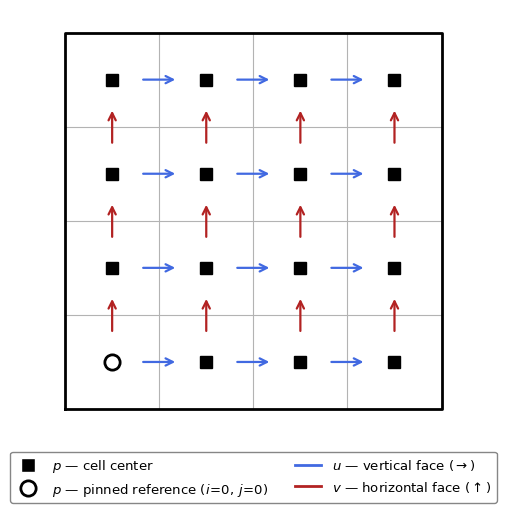

In [109]:
from matplotlib.lines import Line2D

nc = 4  # cells per side in schematic

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.set_aspect('equal')
ax.axis('off')

# grid lines
for k in range(nc + 1):
    ax.plot([0, nc], [k, k], color='0.70', lw=0.8, zorder=1)
    ax.plot([k, k], [0, nc], color='0.70', lw=0.8, zorder=1)
ax.plot([0, nc, nc, 0, 0], [0, 0, nc, nc, 0], 'k-', lw=2.0, zorder=2)

# pressure at cell centers
for i in range(nc):
    for j in range(nc):
        xc, yc = i + 0.5, j + 0.5
        if i == 0 and j == 0:
            ax.plot(xc, yc, 'o', mfc='none', mec='black', ms=11, mew=2.0, zorder=6)
        else:
            ax.plot(xc, yc, 's', color='black', ms=9, zorder=5)

# u-velocity: → arrows at interior vertical faces
alen = 0.20
for i in range(1, nc):
    for j in range(nc):
        ax.annotate('', xy=(i + alen, j + 0.5), xytext=(i - alen, j + 0.5),
                    arrowprops=dict(arrowstyle='->', color='royalblue',
                                   lw=1.6, mutation_scale=13), zorder=4)

# v-velocity: ↑ arrows at interior horizontal faces
for i in range(nc):
    for j in range(1, nc):
        ax.annotate('', xy=(i + 0.5, j + alen), xytext=(i + 0.5, j - alen),
                    arrowprops=dict(arrowstyle='->', color='firebrick',
                                   lw=1.6, mutation_scale=13), zorder=4)

ax.set_xlim(-0.25, nc + 0.25)
ax.set_ylim(-0.25, nc + 0.25)
# ax.set_title('MAC Staggered Grid', fontsize=12, pad=8)

legend_handles = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='black',
           markersize=10, label=r'$p$ — cell center'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor='black', markersize=11, mew=2.0,
           label=r'$p$ — pinned reference ($i\!=\!0,\,j\!=\!0$)'),
    Line2D([0], [0], color='royalblue', lw=2.0,
           label=r'$u$ — vertical face ($\rightarrow$)'),
    Line2D([0], [0], color='firebrick', lw=2.0,
           label=r'$v$ — horizontal face ($\uparrow$)'),
]
ax.legend(handles=legend_handles, loc='upper center',
          bbox_to_anchor=(0.5, -0.03), fontsize=9.5,
          framealpha=0.95, edgecolor='gray', ncol=2)

os.makedirs('report/figs', exist_ok=True)
plt.savefig('report/figs/staggered_grid.pdf', bbox_inches='tight')
plt.show()

## Boundary Conditions

Lid-driven cavity: top wall moves at `Ustar`, all others are no-slip.

In [98]:
# u-velocity BCs — uBC_B/uBC_T shape (nx-1,): one value per interior u-face
uBC_T = Ustar * np.ones(nx - 1)   # top wall moves at Ustar
uBC_B = np.zeros(nx - 1)          # bottom wall: no-slip
uBC_L = np.zeros(ny)              # left wall: no-slip
uBC_R = np.zeros(ny)              # right wall: no-slip

# v-velocity BCs — vBC_L/vBC_R shape (ny-1,): one value per interior v-face
vBC_T = np.zeros(nx)
vBC_B = np.zeros(nx)
vBC_L = np.zeros(ny - 1)
vBC_R = np.zeros(ny - 1)

## Initialization

Start from rest, or load a previous solution from `Results.npz`.

In [99]:
Init_Soln = True   # set False to load from results/Re{Re}.npz

if Init_Soln or not os.path.exists(f'results/Re{int(Re)}.npz'):
    P    = np.zeros(n_cells)
    U    = np.zeros(n_vel)
    time = 0.0
    step = 0
else:
    data = np.load(f'results/Re{int(Re)}.npz')
    P    = data['P']
    U    = data['U']
    time = float(data['time'])
    step = int(data['step'])
    print(f"Loaded solution at t={time:.4f}, step={step}")

## Discrete Operators

### Divergence `D`
Maps velocity vector (length `n_vel`) → pressure space (length `n_cells`).

### Gradient `G`
Maps pressure vector (length `n_cells`) → velocity space (length `n_vel`). **TODO**

### Laplacian `L`
Applies discrete Laplacian to the velocity vector. **TODO**

### Composite operators
| Symbol | Expression | Role |
|--------|-----------|------|
| `S`    | `I + dt/2·ν·L` | Explicit viscous half-step |
| `R`    | `I - dt/2·ν·L` | Implicit viscous half-step (LHS of Step 1) |
| `T`    | `D·S·G`        | Pressure Poisson operator (LHS of Step 2) |
| `C`    | `S·G`          | Velocity correction (Step 3) |

In [100]:
import operators as ops

def laplace_x(x):
    return ops.L(x, dx, iu, iv, nx, ny, n_vel)


def bc_laplace():
    return ops.bc_L(uBC_L, uBC_R, uBC_B, uBC_T,
                    vBC_L, vBC_R, vBC_B, vBC_T,
                    dx, iu, iv, nx, ny, n_vel)


def bc_div():
    return ops.bc_D(uBC_L, uBC_R, vBC_B, vBC_T,
                    dx, ip, nx, ny, n_cells)


def opt_D(x):
    return ops.D(x, dx, ip, iu, iv, nx, ny, n_cells)


def opt_G(x):
    return ops.G(x, dx, ip, iu, iv, nx, ny, n_vel)


def adv(vel):
    return ops.A(vel,
                 uBC_L, uBC_R, uBC_B, uBC_T,
                 vBC_L, vBC_R, vBC_B, vBC_T,
                 dx, iu, iv, nx, ny, n_vel)


def cg_solve(op, b, tol=1e-8):
    A_op = LinearOperator((len(b), len(b)), matvec=op, dtype=np.float64)
    x, info = cg(A_op, b, rtol=tol)
    if info != 0:
        print(f"  CG warning: info={info}")
    return x


def pin_pressure(x):
    """Zero out the ip[0,0] DOF to fix the pressure constant (T = D·S·G is singular)."""
    y = x.copy()
    y[ip[0, 0]] = 0.0
    return y


def opt_S(x):
    return x + (dt / 2.0 * visc) * laplace_x(x)


def opt_R(x):
    return x - (dt / 2.0 * visc) * laplace_x(x)


def opt_T(x):
    return pin_pressure(opt_D(opt_S(opt_G(x))))


def opt_C(x):
    return opt_S(opt_G(x))

## Time Loop — Fractional Step Method

**Step 1** — Solve for intermediate velocity `U*`:
$$
\underbrace{(I - \tfrac{\Delta t}{2}\nu L)}_{R} U^* =
\underbrace{(I + \tfrac{\Delta t}{2}\nu L)}_{S} U^n
+ \Delta t \left(\tfrac{3}{2} N^n - \tfrac{1}{2} N^{n-1}\right)
+ \Delta t\, \nu\, \text{BC}_L
$$

**Step 2** — Solve pressure Poisson equation:
$$
\underbrace{D\,S\,G}_{T}\, P = \frac{1}{\Delta t}\left(D\,U^* + \text{BC}_D\right)
$$

**Step 3** — Correct velocity to enforce $\nabla\cdot U = 0$:
$$
U^{n+1} = U^* - \Delta t\, C\, P
$$

In [101]:
adv_prev = np.zeros(n_vel)   # N(U) at step n-1 for Adams-Bashforth startup

while time < end_time:
    step += 1
    time += dt

    adv0 = adv(U)
    adv1 = adv_prev

    # --- Step 1: intermediate velocity ---
    RHS_U = opt_S(U) + dt * (1.5 * adv0 - 0.5 * adv1) + dt * visc * bc_laplace()
    UF = cg_solve(opt_R, RHS_U, tol=1e-8)

    # --- Step 2: pressure Poisson ---
    # T = D·S·G is singular (null space = constant P); pin ip[0,0] to fix the constant.
    RHS_P = opt_D(UF) / dt + bc_div() / dt
    RHS_P[ip[0, 0]] = 0.0
    P = cg_solve(opt_T, RHS_P, tol=1e-8)

    # --- Step 3: velocity correction ---
    U = UF - dt * opt_C(P)

    adv_prev = adv0

    if step % 100 == 0:
        res = np.linalg.norm(U - UF) / (np.linalg.norm(U) + 1e-15)
        print(f"step={step:5d}  t={time:.4f}  ||U||={np.linalg.norm(U):.4e}  res={res:.2e}")

# Save results
os.makedirs('results', exist_ok=True)
np.savez(f'results/Re{int(Re)}.npz', P=P, U=U, time=time, step=step, Re=Re)

step=  100  t=0.1538  ||U||=9.6145e+00  res=1.69e-02
step=  200  t=0.3077  ||U||=1.1202e+01  res=1.47e-02
step=  300  t=0.4615  ||U||=1.2157e+01  res=1.36e-02
step=  400  t=0.6154  ||U||=1.2834e+01  res=1.29e-02
step=  500  t=0.7692  ||U||=1.3351e+01  res=1.25e-02
step=  600  t=0.9231  ||U||=1.3764e+01  res=1.21e-02
step=  700  t=1.0769  ||U||=1.4104e+01  res=1.19e-02
step=  800  t=1.2308  ||U||=1.4389e+01  res=1.17e-02
step=  900  t=1.3846  ||U||=1.4634e+01  res=1.15e-02
step= 1000  t=1.5385  ||U||=1.4846e+01  res=1.13e-02
step= 1100  t=1.6923  ||U||=1.5033e+01  res=1.12e-02
step= 1200  t=1.8462  ||U||=1.5198e+01  res=1.11e-02
step= 1300  t=2.0000  ||U||=1.5345e+01  res=1.10e-02
step= 1400  t=2.1538  ||U||=1.5477e+01  res=1.09e-02
step= 1500  t=2.3077  ||U||=1.5597e+01  res=1.08e-02
step= 1600  t=2.4615  ||U||=1.5705e+01  res=1.08e-02
step= 1700  t=2.6154  ||U||=1.5804e+01  res=1.07e-02
step= 1800  t=2.7692  ||U||=1.5894e+01  res=1.06e-02
step= 1900  t=2.9231  ||U||=1.5977e+01  res=1.

## Post-Processing / Visualization

In [102]:
# Set True to load saved results for plotting (skips running the solver above)
Load_From_File = False
if Load_From_File:
    fname = f'results/Re{int(Re)}.npz'
    data  = np.load(fname)
    P     = data['P']
    U     = data['U']
    time  = float(data['time'])
    step  = int(data['step'])
    print(f'Loaded {fname}: t={time:.4f}, step={step}')

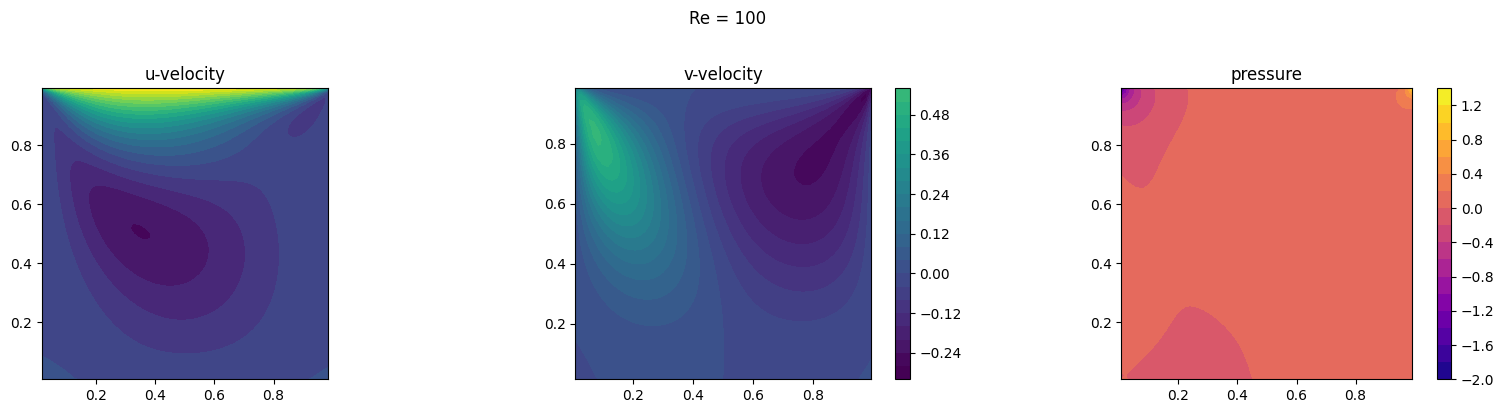

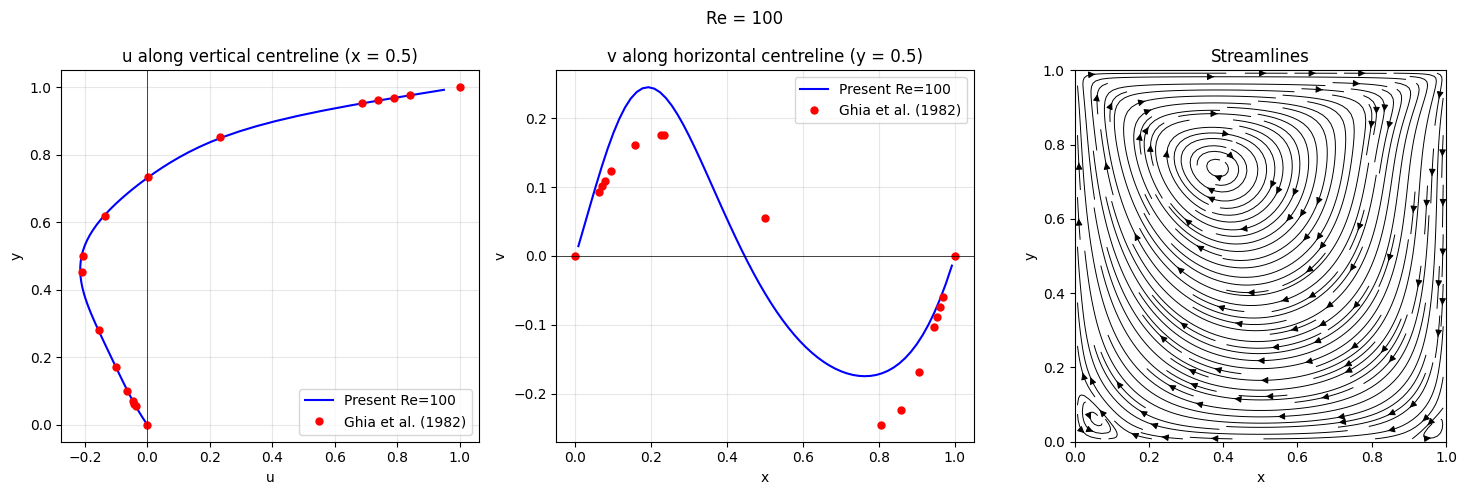

In [103]:
# Ghia et al. (1982) reference data for multiple Re
ghia_re100 = {
    'y_for_u': [1.0000, 0.9766, 0.9688, 0.9609, 0.9531,
                0.8516, 0.7344, 0.6172, 0.5000, 0.4531,
                0.2813, 0.1719, 0.1016, 0.0703, 0.0625,
                0.0547, 0.0000],
    'u':       [ 1.00000,  0.84123,  0.78871,  0.73722,  0.68717,
                 0.23151,  0.00332, -0.13641, -0.20581, -0.21090,
                -0.15662, -0.10150, -0.06434, -0.04775, -0.04192,
                -0.03717,  0.00000],
    'x_for_v': [1.0000, 0.9688, 0.9609, 0.9531, 0.9453,
                0.9063, 0.8594, 0.8047, 0.5000, 0.2344,
                0.2266, 0.1563, 0.0938, 0.0781, 0.0703,
                0.0625, 0.0000],
    'v':       [ 0.00000, -0.05906, -0.07391, -0.08864, -0.10313,
                -0.16914, -0.22445, -0.24533,  0.05454,  0.17527,
                 0.17507,  0.16077,  0.12317,  0.10890,  0.10091,
                 0.09233,  0.00000],
}

ghia_re400 = {
    'y_for_u': [1.0000, 0.9766, 0.9688, 0.9609, 0.9531,
                0.8516, 0.7344, 0.6172, 0.5000, 0.4531,
                0.2813, 0.1719, 0.1016, 0.0703, 0.0625,
                0.0547, 0.0000],
    'u':       [ 1.00000,  0.75837,  0.68439,  0.61756,  0.55892,
                 0.29093,  0.16256,  0.02135, -0.11477, -0.17119,
                -0.32726, -0.24299, -0.14612, -0.10338, -0.09266,
                -0.08186,  0.00000],
    'x_for_v': [1.0000, 0.9688, 0.9609, 0.9531, 0.9453,
                0.9063, 0.8594, 0.8047, 0.5000, 0.2344,
                0.2266, 0.1563, 0.0938, 0.0781, 0.0703,
                0.0625, 0.0000],
    'v':       [ 0.00000, -0.12146, -0.15663, -0.19254, -0.22847,
                -0.23827, -0.44993, -0.38598,  0.05186,  0.30174,
                 0.30203,  0.28124,  0.22965,  0.20920,  0.19713,
                 0.18360,  0.00000],
}

ghia_re1000 = {
    'y_for_u': [1.0000, 0.9766, 0.9688, 0.9609, 0.9531,
                0.8516, 0.7344, 0.6172, 0.5000, 0.4531,
                0.2813, 0.1719, 0.1016, 0.0703, 0.0625,
                0.0547, 0.0000],
    'u':       [ 1.00000,  0.65928,  0.57492,  0.51117,  0.46604,
                 0.33304,  0.18719,  0.05702, -0.06080, -0.10648,
                -0.27805, -0.38289, -0.29730, -0.22220, -0.20196,
                -0.18109,  0.00000],
    'x_for_v': [1.0000, 0.9688, 0.9609, 0.9531, 0.9453,
                0.9063, 0.8594, 0.8047, 0.5000, 0.2344,
                0.2266, 0.1563, 0.0938, 0.0781, 0.0703,
                0.0625, 0.0000],
    'v':       [ 0.00000, -0.21388, -0.27669, -0.33714, -0.39188,
                -0.51550, -0.42665, -0.31966,  0.02526,  0.32235,
                 0.33075,  0.37095,  0.32627,  0.30353,  0.29012,
                 0.27485,  0.00000],
}

ghia_data = {100: ghia_re100, 400: ghia_re400, 1000: ghia_re1000}
ghia = ghia_data[int(Re)]

# --- Reconstruct fields ---
u_2d = U[iu[1:nx, :ny]]    # shape (nx-1, ny)
v_2d = U[iv[:nx, 1:ny]]    # shape (nx, ny-1)
p_2d = P[ip]               # shape (nx, ny)

# --- Contour plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

vmin_vel = min(u_2d.min(), v_2d.min())
vmax_vel = max(u_2d.max(), v_2d.max())

cf_u = axes[0].contourf(xu, yu, u_2d.T, levels=20, vmin=vmin_vel, vmax=vmax_vel, cmap='viridis')
axes[0].set_title('u-velocity'); axes[0].set_aspect('equal')

cf_v = axes[1].contourf(xv, yv, v_2d.T, levels=20, vmin=vmin_vel, vmax=vmax_vel, cmap='viridis')
axes[1].set_title('v-velocity'); axes[1].set_aspect('equal')
fig.colorbar(cf_v, ax=axes[1])

cf_p = axes[2].contourf(xp, yp, p_2d.T, levels=20, cmap='plasma')
axes[2].set_title('pressure'); axes[2].set_aspect('equal')
fig.colorbar(cf_p, ax=axes[2])

fig.suptitle(f'Re = {Re:.0f}', y=1.02)
plt.tight_layout()
plt.show()

# --- u centreline, v centreline, streamlines ---
ix = np.argmin(np.abs(xu - 0.5))
jy = np.argmin(np.abs(yv - 0.5))

u_ext = np.zeros((nx + 1, ny))
u_ext[1:nx, :] = u_2d
u_cc = 0.5 * (u_ext[:nx, :] + u_ext[1:, :])

v_ext = np.zeros((nx, ny + 1))
v_ext[:, 1:ny] = v_2d
v_cc = 0.5 * (v_ext[:, :ny] + v_ext[:, 1:])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
ax.plot(u_2d[ix, :], yp, 'b-', lw=1.5, label=f'Present Re={Re:.0f}')
ax.plot(ghia['u'], ghia['y_for_u'], 'ro', ms=5, label='Ghia et al. (1982)')
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('u'); ax.set_ylabel('y')
ax.set_title(f'u along vertical centreline (x = 0.5)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(xp, v_2d[:, jy], 'b-', lw=1.5, label=f'Present Re={Re:.0f}')
ax.plot(ghia['x_for_v'], ghia['v'], 'ro', ms=5, label='Ghia et al. (1982)')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('x'); ax.set_ylabel('v')
ax.set_title(f'v along horizontal centreline (y = 0.5)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.streamplot(xp, yp, u_cc.T, v_cc.T, density=2, color='k', linewidth=0.7)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.set_title('Streamlines')
ax.set_xlabel('x'); ax.set_ylabel('y')

fig.suptitle(f'Re = {Re:.0f}')
plt.tight_layout(); plt.show()
